# FarmTech Solutions — produtividade agrícola
**Murilo Dias Brandão · RM 573633 · Grupo 84**  
Fase 5 — Machine Learning na cabeça | 08/09/2026

O objetivo é prever o rendimento de quatro culturas e investigar em quais condições climáticas aparecem diferentes padrões de produtividade. A análise usa exclusivamente o `crop_yield.csv` disponibilizado nos assets da atividade.

Este notebook contém o relatório completo. O README reúne a entrada do projeto, a estimativa AWS e as instruções dos extras. O sufixo **pbl_fase4** foi mantido no nome do arquivo porque é o padrão solicitado no enunciado, embora a atividade seja da Fase 5.

**Como executar:** instale `requirements.txt`, deixe o CSV ao lado deste arquivo e execute as células de cima para baixo. Não são necessárias credenciais nem acesso à nuvem. A semente é 42.

In [1]:
# Bibliotecas e semente compartilhadas por todos os experimentos.
from pathlib import Path
import hashlib
import json
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

SEMENTE = 42
PASTA = Path.cwd()
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.titlesize': 13})
print('Python:', platform.python_version(), '| scikit-learn:', sklearn.__version__)

def salvar_figura(nome):
    plt.tight_layout()
    plt.savefig(PASTA / nome, dpi=150, bbox_inches='tight')
    plt.show()

Python: 3.12.10 | scikit-learn: 1.9.0


## 1. Antes dos modelos: conferir a base

Os nomes originais são preservados no CSV. No código, nomes curtos ajudam a leitura. Não há coluna de ano, fazenda ou talhão: por isso não será possível afirmar que a avaliação representa uma previsão de safras futuras.

Há uma inconsistência a conferir com o fornecedor: o enunciado descreve rendimento em toneladas/hectare e precipitação diária, mas o CSV tem rendimentos na casa dos milhares e chuva próxima de 2.000–3.000. Não existe metadado suficiente para assumir outra unidade. **Não divido esses valores por um fator arbitrário.** Métricas e previsões são expressas na unidade original de `Yield`; a conversão para t/ha fica condicionada à confirmação da origem.

In [2]:
# Conferimos o arquivo antes de transformar qualquer variável.
arquivo = PASTA / 'crop_yield.csv'
dados = pd.read_csv(arquivo)
nomes = {
    'Crop': 'cultura',
    'Precipitation (mm day-1)': 'chuva',
    'Specific Humidity at 2 Meters (g/kg)': 'umidade_especifica',
    'Relative Humidity at 2 Meters (%)': 'umidade_relativa',
    'Temperature at 2 Meters (C)': 'temperatura',
    'Yield': 'rendimento',
}
assert set(dados.columns) == set(nomes), 'O esquema do CSV mudou; revise a leitura.'
dados = dados.rename(columns=nomes)
clima = ['chuva', 'umidade_especifica', 'umidade_relativa', 'temperatura']
atributos = ['cultura'] + clima
print('SHA-256:', hashlib.sha256(arquivo.read_bytes()).hexdigest())
print('Linhas e colunas:', dados.shape)
display(dados.head())
display(pd.DataFrame({'tipo': dados.dtypes.astype(str), 'ausentes': dados.isna().sum()}))
print('Linhas integralmente duplicadas:', dados.duplicated().sum())
display(dados.describe(include='all').T)
assert not dados['rendimento'].isna().any(), 'Alvos ausentes precisam ser tratados.'
assert np.isfinite(dados[clima + ['rendimento']].to_numpy()).all()
assert dados['cultura'].notna().all()
assert (dados['rendimento'] >= 0).all()
assert dados['umidade_relativa'].between(0, 100).all()

SHA-256: 07b3335f497e08e705b5835ee334426ac16cb24732c1bfaa994254d39f771b1b
Linhas e colunas: (156, 6)


,cultura,chuva,umidade_especifica,umidade_relativa,temperatura,rendimento
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


,tipo,ausentes
cultura,str,0
chuva,float64,0
umidade_especifica,float64,0
umidade_relativa,float64,0
temperatura,float64,0
rendimento,int64,0


Linhas integralmente duplicadas: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cultura,156,4,"Cocoa, beans",39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chuva,156.0,NaN,NaN,NaN,2486.498974,289.457914,1934.62,2302.99,2424.55,2718.08,3085.79
umidade_especifica,156.0,NaN,NaN,NaN,18.203077,0.293923,17.54,18.03,18.27,18.4,18.7
umidade_relativa,156.0,NaN,NaN,NaN,84.737692,0.996226,82.11,84.12,84.85,85.51,86.1
temperatura,156.0,NaN,NaN,NaN,26.18359,0.26105,25.56,26.02,26.13,26.3,26.81
rendimento,156.0,NaN,NaN,NaN,56153.096154,70421.958897,5249.0,8327.75,18871.0,67518.75,203399.0


### A divisão precisa respeitar os cenários climáticos

As quatro culturas repetem os mesmos perfis meteorológicos. Se simplesmente sortearmos linhas, um cenário pode cair no treino e no teste ao mesmo tempo. Para reduzir esse risco, todas as linhas com o mesmo conjunto de quatro variáveis climáticas ficam no mesmo grupo.

Separamos aproximadamente 20% dos **grupos** para teste e usamos somente o restante para seleção dos algoritmos e hiperparâmetros. A validação cruzada também respeita esses grupos. Os agrupamentos apresentados adiante são descritivos e não são usados como entrada dos regressores.

In [3]:
# O mesmo cenário climático nunca aparece nas duas partições.
grupos = dados.groupby(clima, sort=True).ngroup()
separador = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEMENTE)
idx_treino, idx_teste = next(separador.split(dados[atributos], dados.rendimento, grupos))
X_treino = dados.iloc[idx_treino][atributos].copy()
X_teste = dados.iloc[idx_teste][atributos].copy()
y_treino = dados.iloc[idx_treino].rendimento.copy()
y_teste = dados.iloc[idx_teste].rendimento.copy()
grupos_treino = grupos.iloc[idx_treino]
assert set(grupos_treino).isdisjoint(set(grupos.iloc[idx_teste]))
divisao = pd.DataFrame({'linha_csv': np.arange(len(dados)) + 2, 'grupo_clima': grupos,
                       'particao': np.where(np.isin(np.arange(len(dados)), idx_treino), 'treino', 'teste')})
divisao.to_csv('divisao_dados.csv', index=False)
print(f'{len(dados)} observações, {grupos.nunique()} perfis climáticos, {dados.cultura.nunique()} culturas.')
print(f'Treino: {len(idx_treino)} linhas / {grupos_treino.nunique()} grupos.')
print(f'Teste: {len(idx_teste)} linhas / {grupos.iloc[idx_teste].nunique()} grupos.')
display(pd.crosstab(divisao.particao, dados.cultura))

156 observações, 39 perfis climáticos, 4 culturas.
Treino: 124 linhas / 31 grupos.
Teste: 32 linhas / 8 grupos.


cultura,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
particao,,,,
teste,8,8,8,8
treino,31,31,31,31


## 2. O que os dados mostram

As tabelas e gráficos desta seção descrevem a base fornecida inteira; não são uma avaliação de generalização. A distribuição por cultura deve vir antes de qualquer comparação global, pois o rendimento de culturas diferentes está em escalas muito diferentes.

,count,mean,median,std,min,max
cultura,,,,,,
"Cocoa, beans",39,8883.13,8848.0,1745.03,5765,13056
Oil palm fruit,39,175804.69,175629.0,14919.87,142425,203399
"Rice, paddy",39,32099.67,31101.0,4789.95,24686,42550
"Rubber, natural",39,7824.90,7817.0,1600.26,5249,10285


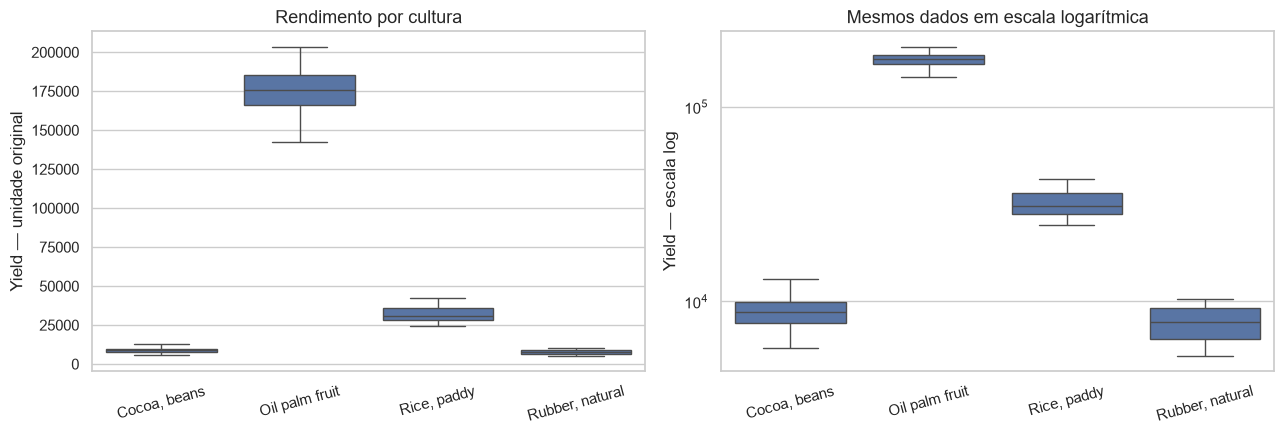

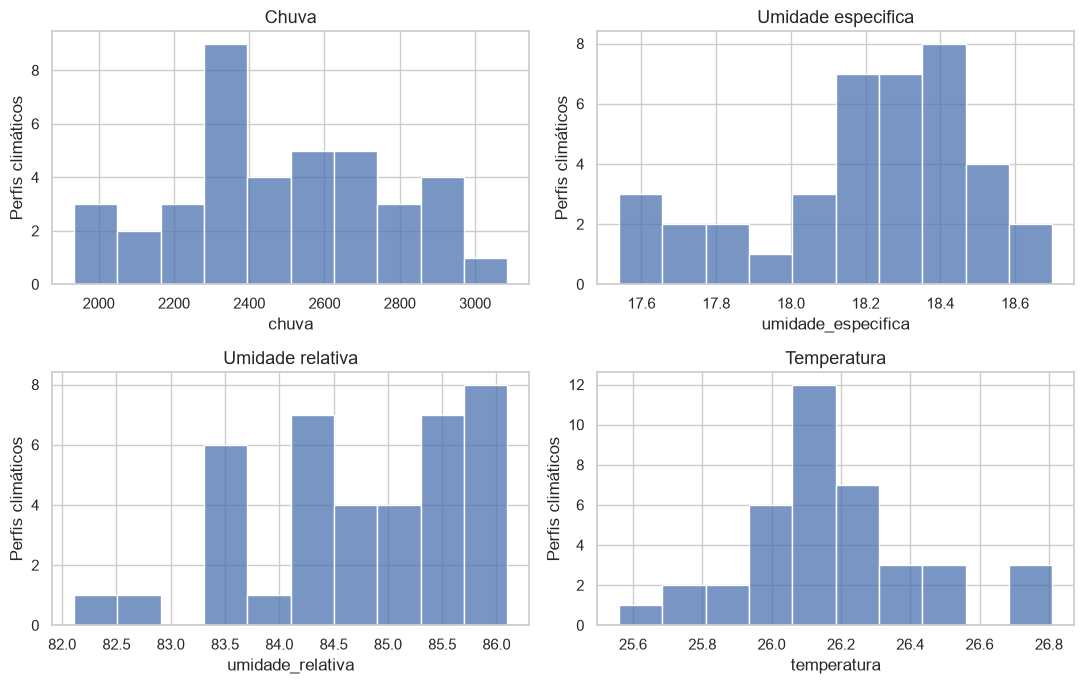

Cada cultura tem **39 registros**. A maior mediana é de **Oil palm fruit** (175,629); diferenças entre culturas podem dominar o desempenho agregado de um modelo.

In [4]:
# A escala log permite enxergar as culturas de menor rendimento.
resumo_culturas = dados.groupby('cultura').rendimento.agg(['count', 'mean', 'median', 'std', 'min', 'max'])
display(resumo_culturas.round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=dados, x='cultura', y='rendimento', ax=axes[0])
axes[0].set(title='Rendimento por cultura', xlabel='', ylabel='Yield — unidade original')
axes[0].tick_params(axis='x', rotation=15)
sns.boxplot(data=dados, x='cultura', y='rendimento', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set(title='Mesmos dados em escala logarítmica', xlabel='', ylabel='Yield — escala log')
axes[1].tick_params(axis='x', rotation=15)
salvar_figura('rendimento_culturas.png')

perfis = dados[clima].drop_duplicates().reset_index(drop=True)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for coluna, ax in zip(clima, axes.flat):
    sns.histplot(perfis[coluna], bins=10, ax=ax)
    ax.set(title=coluna.replace('_', ' ').capitalize(), ylabel='Perfis climáticos')
salvar_figura('distribuicoes_clima.png')
display(Markdown(f'Cada cultura tem **{int(resumo_culturas["count"].min())} registros**. '
                 f'A maior mediana é de **{resumo_culturas["median"].idxmax()}** '
                 f'({resumo_culturas["median"].max():,.0f}); diferenças entre culturas '
                 'podem dominar o desempenho agregado de um modelo.'))

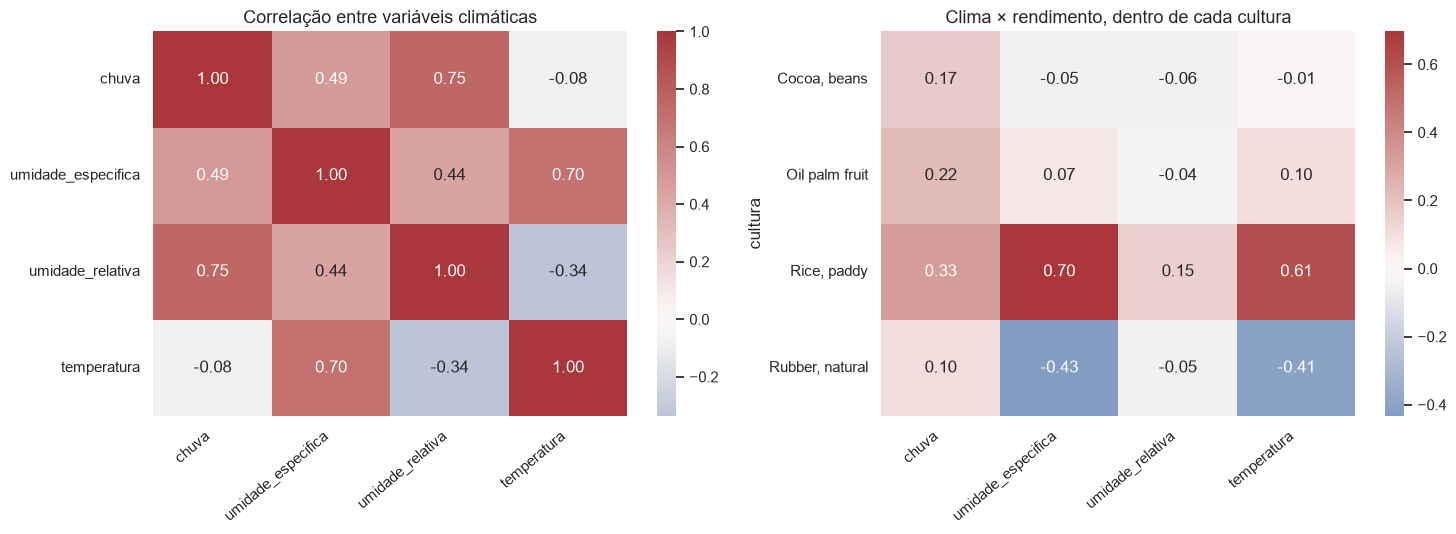

As correlações são associações da amostra, não efeitos causais. Chuva, umidade e temperatura também se relacionam entre si. Sem datas, localização, manejo e qualidade do solo, não podemos isolar o efeito de uma variável nem recomendar intervenções agronômicas.

In [5]:
# Separar por cultura evita misturar relações de escalas diferentes.
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(perfis.corr(), annot=True, fmt='.2f', cmap='vlag', center=0, ax=axes[0])
axes[0].set_title('Correlação entre variáveis climáticas')
correlacoes = dados.groupby('cultura')[clima + ['rendimento']].corr()['rendimento'].unstack()[clima]
sns.heatmap(correlacoes, annot=True, fmt='.2f', cmap='vlag', center=0, ax=axes[1])
axes[1].set_title('Clima × rendimento, dentro de cada cultura')
for ax in axes:
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
salvar_figura('correlacoes.png')
display(Markdown('As correlações são associações da amostra, não efeitos causais. '
                 'Chuva, umidade e temperatura também se relacionam entre si. '
                 'Sem datas, localização, manejo e qualidade do solo, não podemos isolar '
                 'o efeito de uma variável nem recomendar intervenções agronômicas.'))

## 3. Agrupamentos: quais cenários se parecem?

O K-Means usa somente as quatro variáveis climáticas, padronizadas, e apenas um exemplar de cada perfil. Assim a repetição entre culturas não pesa quatro vezes na escolha dos grupos. Avalio de 2 a 6 grupos pela silhueta e interpreto o rendimento **depois** do agrupamento. Incluir o próprio rendimento no agrupamento e chamar isso de previsão seria circular.

Como há apenas 39 perfis, o resultado é exploratório. A silhueta ajuda na escolha, mas não prova a existência de regimes agrícolas reais. A projeção PCA serve apenas para visualizar os grupos.

,k,silhueta,inercia
0,2,0.3677,95.0129
1,3,0.3987,56.7984
2,4,0.3824,46.1212
3,5,0.3764,34.8500
4,6,0.3695,29.0960


,chuva,umidade_especifica,umidade_relativa,temperatura,rendimento_relativo
cluster,,,,,
0,2733.518,18.338,85.652,26.119,1.020
1,2359.025,18.393,84.145,26.481,1.007
2,2232.217,17.805,83.916,25.986,0.996


cultura,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
cluster,,,,
0,17,17,17,17
1,11,11,11,11
2,11,11,11,11


count       mean    median
cluster cultura                                    
0       Cocoa, beans        17    8947.59    8300.0
        Oil palm fruit      17  177074.18  175629.0
        Rice, paddy         17   33147.94   33260.0
        Rubber, natural     17    7776.47    7435.0
1       Cocoa, beans        11    8819.27    8226.0
        Oil palm fruit      11  178607.55  181496.0
        Rice, paddy         11   35576.55   36361.0
        Rubber, natural     11    6808.64    6275.0
2       Cocoa, beans        11    8847.36    9003.0
        Oil palm fruit      11  171039.91  169783.0
        Rice, paddy         11   27002.73   26648.0
        Rubber, natural     11    8916.00    9322.0

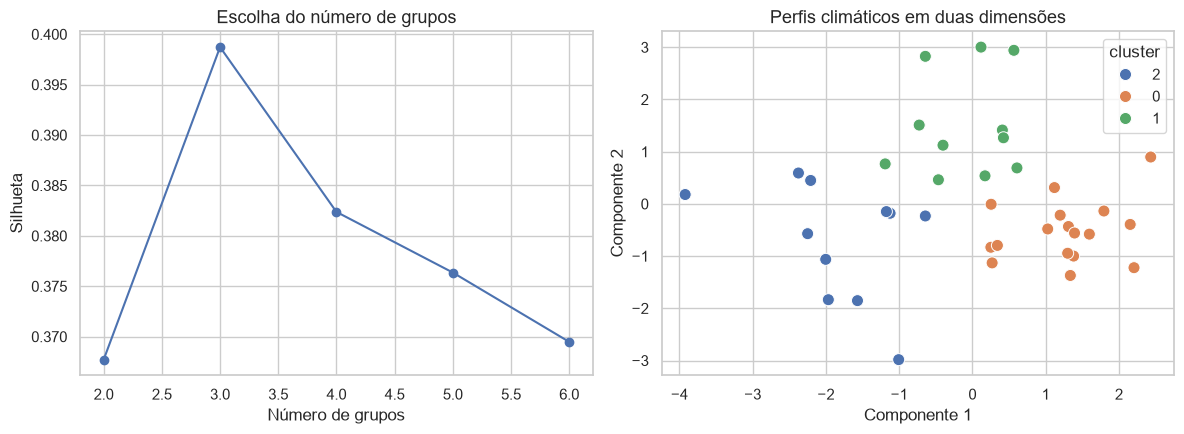

k escolhido: 3; silhueta: 0.399.
Variância representada no PCA: 93.4%.
ARI entre inicializações: mínimo=1.000, média=1.000.


In [6]:
# A padronização impede que a chuva domine a distância só pela escala.
escala_clima = StandardScaler()
clima_padronizado = escala_clima.fit_transform(perfis)
avaliacao_k = []
for k in range(2, 7):
    agrupador = KMeans(n_clusters=k, n_init=30, random_state=SEMENTE)
    rotulos = agrupador.fit_predict(clima_padronizado)
    avaliacao_k.append({'k': k, 'silhueta': silhouette_score(clima_padronizado, rotulos),
                        'inercia': agrupador.inertia_})
avaliacao_k = pd.DataFrame(avaliacao_k)
display(avaliacao_k.round(4))
melhor_k = int(avaliacao_k.loc[avaliacao_k.silhueta.idxmax(), 'k'])
kmeans = KMeans(n_clusters=melhor_k, n_init=30, random_state=SEMENTE)
perfis['cluster'] = kmeans.fit_predict(clima_padronizado)
exploracao = dados.merge(perfis, on=clima, validate='many_to_one')
exploracao['rendimento_relativo'] = exploracao.rendimento / exploracao.groupby('cultura').rendimento.transform('median')
display(exploracao.groupby('cluster')[clima + ['rendimento_relativo']].mean().round(3))
display(pd.crosstab(exploracao.cluster, exploracao.cultura))
display(exploracao.groupby(['cluster', 'cultura']).rendimento.agg(['count', 'mean', 'median']).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(avaliacao_k.k, avaliacao_k.silhueta, marker='o')
axes[0].set(xlabel='Número de grupos', ylabel='Silhueta', title='Escolha do número de grupos')
pca = PCA(n_components=2)
projecao = pca.fit_transform(clima_padronizado)
sns.scatterplot(x=projecao[:, 0], y=projecao[:, 1], hue=perfis.cluster.astype(str), s=75, ax=axes[1])
axes[1].set(xlabel='Componente 1', ylabel='Componente 2', title='Perfis climáticos em duas dimensões')
salvar_figura('clusters.png')
estabilidade = [adjusted_rand_score(perfis.cluster, KMeans(n_clusters=melhor_k, n_init=30,
                random_state=s).fit_predict(clima_padronizado)) for s in range(10)]
print(f'k escolhido: {melhor_k}; silhueta: {avaliacao_k.silhueta.max():.3f}.')
print(f'Variância representada no PCA: {pca.explained_variance_ratio_.sum():.1%}.')
print(f'ARI entre inicializações: mínimo={min(estabilidade):.3f}, média={np.mean(estabilidade):.3f}.')
exploracao.to_csv('perfis_e_clusters.csv', index=False)

In [7]:
# Rendimento relativo compara cada cultura com sua própria mediana.
centros = perfis.groupby('cluster')[clima].mean()
mais_chuvoso = int(centros.chuva.idxmax())
mais_quente = int(centros.temperatura.idxmax())
display(Markdown(f'O grupo **{mais_chuvoso}** tem a maior chuva média '
                 f'({centros.loc[mais_chuvoso, "chuva"]:,.1f} na escala do CSV); '
                 f'o grupo **{mais_quente}** tem a maior temperatura média '
                 f'({centros.loc[mais_quente, "temperatura"]:.2f} °C). '
                 'Os números dos grupos são identificadores arbitrários, sem ordem de qualidade.'))
tendencias = exploracao.groupby(['cultura', 'cluster']).rendimento_relativo.mean().unstack()
display(tendencias.round(3))
display(Markdown('Na tabela, **1,00** corresponde à mediana histórica da própria cultura. '
                 'Valores maiores indicam rendimento relativo maior naquele grupo. '
                 'A comparação dentro da cultura evita chamar um plantio de palma de mais '
                 'saudável apenas porque ele produz mais massa que cacau. '
                 'As diferenças sugerem cenários para investigar; não garantem que mudar '
                 'o clima levaria ao mesmo resultado.'))

O grupo **0** tem a maior chuva média (2,733.5 na escala do CSV); o grupo **1** tem a maior temperatura média (26.48 °C). Os números dos grupos são identificadores arbitrários, sem ordem de qualidade.

cluster,0,1,2
cultura,,,
"Cocoa, beans",1.011,0.997,1.000
Oil palm fruit,1.008,1.017,0.974
"Rice, paddy",1.066,1.144,0.868
"Rubber, natural",0.995,0.871,1.141


Na tabela, **1,00** corresponde à mediana histórica da própria cultura. Valores maiores indicam rendimento relativo maior naquele grupo. A comparação dentro da cultura evita chamar um plantio de palma de mais saudável apenas porque ele produz mais massa que cacau. As diferenças sugerem cenários para investigar; não garantem que mudar o clima levaria ao mesmo resultado.

### Cenários discrepantes

Uso duas leituras complementares: IQR do rendimento **dentro de cada cultura** e Local Outlier Factor nos perfis climáticos padronizados. O LOF compara densidades locais; a contaminação de 10% é uma escolha exploratória, não uma taxa conhecida de erro. Mostro também o resultado com 5% para deixar a sensibilidade explícita. Nenhuma dessas flags é usada para apagar registros ou melhorar artificialmente as métricas.

In [8]:
# As flags servem para revisão; nenhum registro é excluído.
q1 = dados.groupby('cultura').rendimento.transform(lambda s: s.quantile(.25))
q3 = dados.groupby('cultura').rendimento.transform(lambda s: s.quantile(.75))
iqr = q3 - q1
flag_rendimento = (dados.rendimento < q1 - 1.5 * iqr) | (dados.rendimento > q3 + 1.5 * iqr)
lof = LocalOutlierFactor(n_neighbors=10, contamination=.10)
perfis['outlier_clima'] = lof.fit_predict(clima_padronizado) == -1
perfis['score_lof'] = -lof.negative_outlier_factor_
flags = dados.merge(perfis[clima + ['outlier_clima', 'score_lof']], on=clima, validate='many_to_one')
flags['outlier_rendimento'] = flag_rendimento.to_numpy()
print('Outliers de rendimento (IQR por cultura):', int(flag_rendimento.sum()))
print('Perfis sinalizados por LOF (10%):', int(perfis.outlier_clima.sum()))
for taxa in [.05, .10]:
    sinal = LocalOutlierFactor(n_neighbors=10, contamination=taxa).fit_predict(clima_padronizado)
    print(f'LOF com contaminação {taxa:.0%}: {(sinal == -1).sum()} perfis')
display(perfis.sort_values('score_lof', ascending=False).head(6))
display(flags.loc[flags.outlier_rendimento | flags.outlier_clima])
flags.to_csv('outliers.csv', index=False)
display(Markdown('Uma flag climática se repete nas quatro culturas porque elas compartilham '
                 'o mesmo perfil. Isso não significa quatro eventos meteorológicos independentes. '
                 'Antes de excluir algo, seria preciso conferir a medição e os metadados com a fazenda.'))

Outliers de rendimento (IQR por cultura): 0
Perfis sinalizados por LOF (10%): 4
LOF com contaminação 5%: 2 perfis
LOF com contaminação 10%: 4 perfis


,chuva,umidade_especifica,umidade_relativa,temperatura,cluster,outlier_clima,score_lof
3,2592.35,17.61,85.07,25.56,2,True,1.650197
1,1938.42,17.54,82.11,26.11,2,True,1.418096
36,2967.41,18.67,85.48,26.46,0,True,1.389162
35,2410.13,18.58,83.45,26.81,1,True,1.367373
17,2362.80,18.70,84.03,26.79,1,False,1.367233
38,2109.34,18.51,83.52,26.72,1,False,1.296674


,cultura,chuva,umidade_especifica,umidade_relativa,temperatura,rendimento,outlier_clima,score_lof,outlier_rendimento
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253,True,1.418096,False
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321,True,1.650197,False
35,"Cocoa, beans",2410.13,18.58,83.45,26.81,11487,True,1.367373,False
36,"Cocoa, beans",2967.41,18.67,85.48,26.46,7314,True,1.389162,False
40,Oil palm fruit,1938.42,17.54,82.11,26.11,201436,True,1.418096,False
42,Oil palm fruit,2592.35,17.61,85.07,25.56,181826,True,1.650197,False
74,Oil palm fruit,2410.13,18.58,83.45,26.81,172601,True,1.367373,False
75,Oil palm fruit,2967.41,18.67,85.48,26.46,199074,True,1.389162,False
79,"Rice, paddy",1938.42,17.54,82.11,26.11,27619,True,1.418096,False
81,"Rice, paddy",2592.35,17.61,85.07,25.56,25187,True,1.650197,False


Uma flag climática se repete nas quatro culturas porque elas compartilham o mesmo perfil. Isso não significa quatro eventos meteorológicos independentes. Antes de excluir algo, seria preciso conferir a medição e os metadados com a fazenda.

## 4. Cinco algoritmos, com a mesma avaliação

Comparo regressão linear, árvore de decisão, floresta aleatória, gradient boosting e SVR. A regressão linear é a referência simples; árvores capturam cortes e interações; a floresta reduz a variância de uma árvore; boosting corrige erros sequencialmente; SVR testa uma relação não linear suave.

Imputação, padronização e one-hot encoding ficam dentro do pipeline, ajustados em cada dobra. A base atual não tem faltantes; a imputação permite reutilizar o pipeline sem aprender estatísticas no teste. No SVR o alvo também é padronizado dentro de cada ajuste, pois sua escala original prejudicaria a escolha de C e epsilon.

**Critério de escolha:** menor MAE médio em validação cruzada com cinco dobras por grupo. MAE mantém a unidade do alvo; RMSE evidencia erros grandes; R² mede desempenho relativo à média. O teste fica reservado até a escolha. As grades são pequenas, coerentes com o tamanho da base e com o prazo, sem uma busca excessiva que favoreceria sobreajuste à validação.

In [9]:
# Cada dobra aprende seu próprio pré-processamento, sem usar o teste.
numerico = Pipeline([('imputar', SimpleImputer(strategy='median')),
                     ('padronizar', StandardScaler())])
categorico = Pipeline([('imputar', SimpleImputer(strategy='most_frequent')),
                       ('codificar', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preparo = ColumnTransformer([('numerico', numerico, clima), ('cultura', categorico, ['cultura'])])
modelos = {
    'Regressão linear': (LinearRegression(), {}),
    'Árvore de decisão': (DecisionTreeRegressor(random_state=SEMENTE),
                         {'modelo__max_depth': [3, 5, None], 'modelo__min_samples_leaf': [2, 5]}),
    'Floresta aleatória': (RandomForestRegressor(n_estimators=250, random_state=SEMENTE, n_jobs=1),
                          {'modelo__max_depth': [4, None], 'modelo__min_samples_leaf': [2, 5]}),
    'Gradient boosting': (GradientBoostingRegressor(random_state=SEMENTE),
                          {'modelo__n_estimators': [80, 150], 'modelo__max_depth': [1, 2],
                           'modelo__learning_rate': [.05, .1]}),
    'SVR': (TransformedTargetRegressor(regressor=SVR(kernel='rbf'), transformer=StandardScaler()),
            {'modelo__regressor__C': [1, 10, 100], 'modelo__regressor__epsilon': [.01, .1],
             'modelo__regressor__gamma': ['scale', .05]}),
}
cv = list(GroupKFold(n_splits=5).split(X_treino, y_treino, grupos_treino))
for tr, va in cv:
    assert set(grupos_treino.iloc[tr]).isdisjoint(set(grupos_treino.iloc[va]))
buscas, comparacao = {}, []
for nome, (estimador, grade) in modelos.items():
    pipeline = Pipeline([('preparo', clone(preparo)), ('modelo', estimador)])
    busca = GridSearchCV(pipeline, grade, cv=cv, scoring={'mae': 'neg_mean_absolute_error',
                        'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'},
                        refit='mae', n_jobs=1, error_score='raise')
    busca.fit(X_treino, y_treino)
    buscas[nome] = busca
    i = busca.best_index_
    comparacao.append({'modelo': nome, 'MAE_CV': -busca.cv_results_['mean_test_mae'][i],
                       'desvio_MAE_CV': busca.cv_results_['std_test_mae'][i],
                       'RMSE_CV': -busca.cv_results_['mean_test_rmse'][i],
                       'R2_CV': busca.cv_results_['mean_test_r2'][i],
                       'parametros': str(busca.best_params_)})
    print(nome, 'concluído')
comparacao = pd.DataFrame(comparacao).sort_values('MAE_CV').reset_index(drop=True)
escolhido = comparacao.loc[0, 'modelo']
display(comparacao.round(3))
comparacao.to_csv('comparacao_modelos.csv', index=False)
print('Escolhido exclusivamente pela validação:', escolhido)

Regressão linear concluído


Árvore de decisão concluído


Floresta aleatória concluído


Gradient boosting concluído


SVR concluído


,modelo,MAE_CV,desvio_MAE_CV,RMSE_CV,R2_CV,parametros
0,Floresta aleatória,4414.737,543.688,7902.359,0.987,"{'modelo__max_depth': None, 'modelo__min_sampl..."
1,Árvore de decisão,4619.074,483.095,9324.147,0.982,"{'modelo__max_depth': None, 'modelo__min_sampl..."
2,Gradient boosting,4772.344,834.224,7927.604,0.987,"{'modelo__learning_rate': 0.1, 'modelo__max_de..."
3,Regressão linear,5425.592,836.961,8594.692,0.985,{}
4,SVR,6646.820,2746.711,10362.132,0.977,"{'modelo__regressor__C': 100, 'modelo__regress..."


Escolhido exclusivamente pela validação: Floresta aleatória


### Uma comparação que não pode faltar: saber a cultura já resolve quanto?

Um R² global alto pode vir quase todo da diferença entre palma e cacau. Além de uma média global, calculo uma referência que prevê apenas a média de rendimento de cada cultura, estimada no treino de cada dobra. Se os modelos não superarem essa referência, não há evidência de que as variáveis climáticas acrescentaram valor preditivo nessa avaliação.

In [10]:
# A referência por cultura também aprende somente no treino da dobra.
baseline_cv = []
for tr, va in cv:
    tabela = pd.DataFrame({'cultura': X_treino.iloc[tr].cultura, 'y': y_treino.iloc[tr]})
    medias = tabela.groupby('cultura').y.mean()
    previsto = X_treino.iloc[va].cultura.map(medias).fillna(y_treino.iloc[tr].mean())
    baseline_cv.append(mean_absolute_error(y_treino.iloc[va], previsto))
print(f'Baseline por cultura — MAE CV: {np.mean(baseline_cv):,.2f} ± {np.std(baseline_cv):,.2f}')
print(f'Melhor dos cinco — MAE CV: {comparacao.loc[0, "MAE_CV"]:,.2f}')
ganho_cv = 1 - comparacao.loc[0, 'MAE_CV'] / np.mean(baseline_cv)
display(Markdown(f'Ganho relativo de MAE sobre a média por cultura: **{ganho_cv:.1%}**. '
                 'Um valor negativo significa que a referência simples foi melhor. '
                 'Mesmo nesse caso, os cinco modelos são apresentados e a limitação é mantida no relatório.'))

Baseline por cultura — MAE CV: 5,180.89 ± 696.72
Melhor dos cinco — MAE CV: 4,414.74


Ganho relativo de MAE sobre a média por cultura: **14.8%**. Um valor negativo significa que a referência simples foi melhor. Mesmo nesse caso, os cinco modelos são apresentados e a limitação é mantida no relatório.

## 5. Teste final e análise dos erros

A escolha já foi feita. Avalio os cinco algoritmos no mesmo teste para documentar a comparação, sem trocar o vencedor com base nesses resultados. O erro por cultura é essencial: uma boa métrica global pode esconder desempenho fraco em uma cultura específica.

,modelo,MAE,RMSE,R2
0,Regressão linear,3985.566,5412.861,0.994
1,Árvore de decisão,3701.181,6446.334,0.991
2,Floresta aleatória,3669.238,5172.422,0.994
3,Gradient boosting,3932.856,5686.289,0.993
4,SVR,3914.646,5711.404,0.993
5,Baseline: média global,59215.183,69396.447,-0.000
6,Baseline: média da cultura,4077.381,5427.703,0.994


,cultura,n,MAE,RMSE,R2,MAE_baseline,MAE_sobre_media_pct
0,"Cocoa, beans",8,1624.521,1827.689,-0.169,1550.254,16.764
1,Oil palm fruit,8,8805.847,9341.653,-0.044,8895.355,5.034
2,"Rice, paddy",8,2791.846,3656.390,0.462,4025.040,8.517
3,"Rubber, natural",8,1454.740,1743.470,0.138,1838.875,18.589


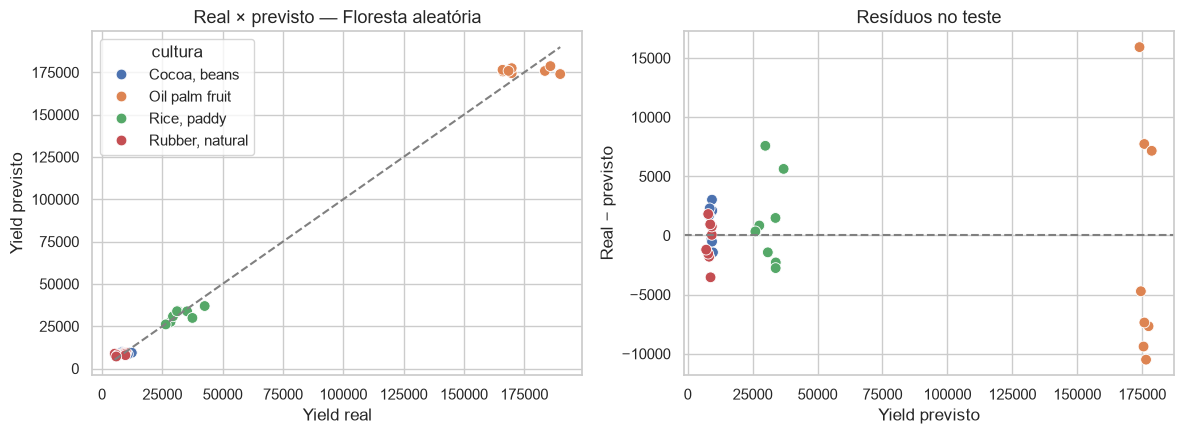

In [11]:
# O vencedor já foi escolhido pela validação antes de abrir o teste.
def metricas(real, previsto):
    return {'MAE': mean_absolute_error(real, previsto),
            'RMSE': root_mean_squared_error(real, previsto), 'R2': r2_score(real, previsto)}

resultados_teste = []
for nome, busca in buscas.items():
    resultados_teste.append({'modelo': nome, **metricas(y_teste, busca.predict(X_teste))})
dummy = DummyRegressor(strategy='mean').fit(X_treino, y_treino)
resultados_teste.append({'modelo': 'Baseline: média global', **metricas(y_teste, dummy.predict(X_teste))})
medias_treino = pd.DataFrame({'cultura': X_treino.cultura, 'y': y_treino}).groupby('cultura').y.mean()
pred_baseline = X_teste.cultura.map(medias_treino).fillna(y_treino.mean())
resultados_teste.append({'modelo': 'Baseline: média da cultura', **metricas(y_teste, pred_baseline)})
resultados_teste = pd.DataFrame(resultados_teste)
display(resultados_teste.round(3))
resultados_teste.to_csv('metricas_teste.csv', index=False)

pred = buscas[escolhido].predict(X_teste)
erros = X_teste.copy()
erros['real'] = y_teste
erros['previsto'] = pred
erros['residuo'] = erros.real - erros.previsto
erros['baseline'] = pred_baseline
por_cultura = []
for cultura, parte in erros.groupby('cultura'):
    med = metricas(parte.real, parte.previsto)
    por_cultura.append({'cultura': cultura, 'n': len(parte), **med,
                        'MAE_baseline': mean_absolute_error(parte.real, parte.baseline),
                        'MAE_sobre_media_pct': 100 * med['MAE'] / parte.real.mean()})
por_cultura = pd.DataFrame(por_cultura)
display(por_cultura.round(3))
por_cultura.to_csv('metricas_por_cultura.csv', index=False)
erros.to_csv('predicoes_teste.csv', index_label='indice_original')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=erros, x='real', y='previsto', hue='cultura', ax=axes[0], s=60)
limites = [min(erros.real.min(), erros.previsto.min()), max(erros.real.max(), erros.previsto.max())]
axes[0].plot(limites, limites, '--', color='gray')
axes[0].set(title=f'Real × previsto — {escolhido}', xlabel='Yield real', ylabel='Yield previsto')
sns.scatterplot(data=erros, x='previsto', y='residuo', hue='cultura', ax=axes[1], legend=False, s=60)
axes[1].axhline(0, ls='--', color='gray')
axes[1].set(title='Resíduos no teste', xlabel='Yield previsto', ylabel='Real − previsto')
salvar_figura('erros_teste.png')

### Incerteza da avaliação

O teste tem poucos cenários independentes. Um intervalo por bootstrap de **grupos**, mantendo juntas as culturas do cenário sorteado, mostra a variação do MAE nesse conjunto. É um diagnóstico aproximado do teste atual, não um intervalo de previsão para uma nova safra nem uma garantia de desempenho futuro.

In [12]:
# Reamostramos cenários inteiros para respeitar a dependência das linhas.
rng = np.random.default_rng(SEMENTE)
grupo_teste = grupos.iloc[idx_teste].to_numpy()
unicos = np.unique(grupo_teste)
maes_bootstrap = []
for _ in range(2000):
    sorteados = rng.choice(unicos, size=len(unicos), replace=True)
    indices = np.concatenate([np.flatnonzero(grupo_teste == g) for g in sorteados])
    maes_bootstrap.append(mean_absolute_error(y_teste.iloc[indices], pred[indices]))
inferior, superior = np.percentile(maes_bootstrap, [2.5, 97.5])
metrica_final = metricas(y_teste, pred)
print(f'MAE do escolhido: {metrica_final["MAE"]:,.2f}')
print(f'Intervalo percentil aproximado de 95% por grupos: [{inferior:,.2f}; {superior:,.2f}]')
print('Grupos independentes no teste:', len(unicos))

MAE do escolhido: 3,669.24
Intervalo percentil aproximado de 95% por grupos: [2,835.09; 4,471.16]
Grupos independentes no teste: 8


In [13]:
# A conclusão usa as métricas realmente calculadas nesta execução.
mae_baseline = mean_absolute_error(y_teste, pred_baseline)
pior = por_cultura.loc[por_cultura.MAE_sobre_media_pct.idxmax()]
display(Markdown(f"""## 6. Conclusão

O algoritmo selecionado pela validação foi **{escolhido}**, com MAE CV de **{comparacao.loc[0, 'MAE_CV']:,.2f}**. No teste reservado, o MAE foi **{metrica_final['MAE']:,.2f}**, o RMSE **{metrica_final['RMSE']:,.2f}** e o R² **{metrica_final['R2']:.3f}**, todos na escala original do alvo quando aplicável.

A referência que usa somente a cultura teve MAE de **{mae_baseline:,.2f}** no teste. A redução relativa de erro do modelo foi **{1 - metrica_final['MAE'] / mae_baseline:.1%}**. Esse confronto é mais informativo sobre o valor adicional do clima do que olhar apenas o R² agregado. A cultura com maior MAE proporcional à sua média foi **{pior['cultura']}**, com **{pior['MAE_sobre_media_pct']:.1f}%**.

O K-Means separou **{melhor_k} cenários**, com silhueta **{avaliacao_k.silhueta.max():.3f}**. As médias de rendimento dentro de cada cultura ajudam a descrever esses cenários, mas não estabelecem causalidade. IQR e LOF apontam observações para revisão, preservadas na modelagem.

Os R² negativos de cacau e palma no teste mostram que o modelo não explica bem a variação interna dessas culturas, apesar do R² global alto. O desempenho agregado é favorecido pelas diferenças de escala entre culturas. Essa é uma razão concreta para não apresentar o sistema como pronto para decisões de produção.

**Pontos fortes:** arquivo original verificável, divisão por cenários sem sobreposição, transformações ajustadas dentro da validação, cinco algoritmos distintos, duas referências simples, avaliação por cultura e execução reproduzível.

**Limitações:** apenas 39 perfis climáticos; ausência de datas, localização e manejo; escalas/unidades a confirmar; correlação entre variáveis; poucos grupos no teste e possibilidade de dependência temporal que não pode ser reconstruída. Não é adequado extrapolar para novas culturas ou condições muito fora da amostra. Um bom resultado neste CSV não valida a solução em uma fazenda real.

**Próximos passos:** confirmar unidades e período das medições; reunir dados reais de mais safras e talhões; separar uma safra posterior para validação temporal; medir latência, memória e estabilidade da API na infraestrutura escolhida; monitorar os erros após implantação. Treinamento e busca ficam fora da máquina de 1 GiB; ela seria usada apenas para uma inferência leve, após teste de carga.
"""))

## 6. Conclusão

O algoritmo selecionado pela validação foi **Floresta aleatória**, com MAE CV de **4,414.74**. No teste reservado, o MAE foi **3,669.24**, o RMSE **5,172.42** e o R² **0.994**, todos na escala original do alvo quando aplicável.

A referência que usa somente a cultura teve MAE de **4,077.38** no teste. A redução relativa de erro do modelo foi **10.0%**. Esse confronto é mais informativo sobre o valor adicional do clima do que olhar apenas o R² agregado. A cultura com maior MAE proporcional à sua média foi **Rubber, natural**, com **18.6%**.

O K-Means separou **3 cenários**, com silhueta **0.399**. As médias de rendimento dentro de cada cultura ajudam a descrever esses cenários, mas não estabelecem causalidade. IQR e LOF apontam observações para revisão, preservadas na modelagem.

Os R² negativos de cacau e palma no teste mostram que o modelo não explica bem a variação interna dessas culturas, apesar do R² global alto. O desempenho agregado é favorecido pelas diferenças de escala entre culturas. Essa é uma razão concreta para não apresentar o sistema como pronto para decisões de produção.

**Pontos fortes:** arquivo original verificável, divisão por cenários sem sobreposição, transformações ajustadas dentro da validação, cinco algoritmos distintos, duas referências simples, avaliação por cultura e execução reproduzível.

**Limitações:** apenas 39 perfis climáticos; ausência de datas, localização e manejo; escalas/unidades a confirmar; correlação entre variáveis; poucos grupos no teste e possibilidade de dependência temporal que não pode ser reconstruída. Não é adequado extrapolar para novas culturas ou condições muito fora da amostra. Um bom resultado neste CSV não valida a solução em uma fazenda real.

**Próximos passos:** confirmar unidades e período das medições; reunir dados reais de mais safras e talhões; separar uma safra posterior para validação temporal; medir latência, memória e estabilidade da API na infraestrutura escolhida; monitorar os erros após implantação. Treinamento e busca ficam fora da máquina de 1 GiB; ela seria usada apenas para uma inferência leve, após teste de carga.


## 7. Artefato para inferência

O modelo abaixo é reajustado em toda a base **somente depois** de encerrar a avaliação. As métricas acima pertencem ao modelo treinado apenas na partição de treino; não são métricas de teste do reajuste final. O arquivo exportado é consumido por `api.py`. Arquivos joblib só devem ser carregados quando a origem for confiável.

Referências técnicas: [pipelines e prevenção de vazamento](https://scikit-learn.org/stable/common_pitfalls.html), [validação por grupos](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators-for-grouped-data), [métricas de regressão](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics), [clustering](https://scikit-learn.org/stable/modules/clustering.html), [LOF](https://scikit-learn.org/stable/modules/outlier_detection.html#local-outlier-factor).

In [14]:
# Reajuste final para inferência; não altera a avaliação anterior.
modelo_final = clone(buscas[escolhido].best_estimator_).fit(dados[atributos], dados.rendimento)
joblib.dump(modelo_final, 'modelo_rendimento.joblib')
metadados = {
    'modelo': escolhido, 'semente': SEMENTE,
    'culturas': sorted(dados.cultura.unique().tolist()),
    'atributos': atributos,
    'faixas': {c: {'min': float(dados[c].min()), 'max': float(dados[c].max())} for c in clima},
    'unidade_alvo': 'unidade original de Yield; conversão para t/ha pendente de confirmação',
    'sha256_csv': hashlib.sha256(arquivo.read_bytes()).hexdigest(),
    'sklearn': sklearn.__version__, 'metricas_teste_antes_reajuste': metrica_final,
    'mae_baseline_cultura': float(mae_baseline),
    'intervalo_mae_bootstrap': [float(inferior), float(superior)],
    'k_clusters': melhor_k, 'silhueta': float(avaliacao_k.silhueta.max()),
}
Path('modelo_metadados.json').write_text(json.dumps(metadados, ensure_ascii=False, indent=2), encoding='utf-8')
exemplo = dados.iloc[0][atributos].to_dict()
Path('exemplo_previsao.json').write_text(json.dumps(exemplo, ensure_ascii=False, indent=2), encoding='utf-8')
recarregado = joblib.load('modelo_rendimento.joblib')
assert np.allclose(modelo_final.predict(dados[atributos].head()), recarregado.predict(dados[atributos].head()))
print('Exemplo de entrada:', exemplo)
print('Previsão do modelo reajustado:', float(recarregado.predict(pd.DataFrame([exemplo]))[0]))
print('Artefato salvo e recarregado com a mesma previsão.')

Exemplo de entrada: {'cultura': 'Cocoa, beans', 'chuva': 2248.92, 'umidade_especifica': 17.72, 'umidade_relativa': 83.4, 'temperatura': 26.01}
Previsão do modelo reajustado: 10248.385104761903
Artefato salvo e recarregado com a mesma previsão.
